<a href="https://colab.research.google.com/github/tanmayrathi/ML-PRACTICAL/blob/main/ML9(CS23062).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tanmay Rathi (CS23062)

Aim: To implement the K-Means clustering algorithm and analyze the clustering results using appropriate evaluation techniques.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path="/content/drive/MyDrive/ML_Data/Mall_Customers - Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df[df.isnull().any(axis=1)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
X = pd.get_dummies(X, dtype=int)

In [ ]:
X.shape

(200, 2)

In [ ]:
X.head(5)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
X.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


Text(0.5, 1.0, 'Elbow Method for Optimal K')

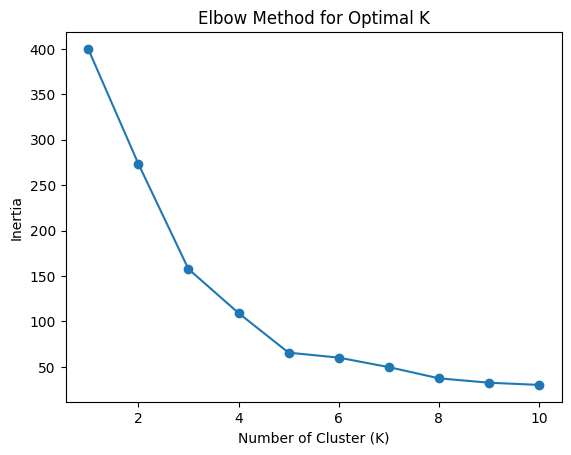

In [ ]:
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)

print(inertia_values)
plt.figure()
plt.plot(range(1,11), inertia_values, marker='o')
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)


















Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


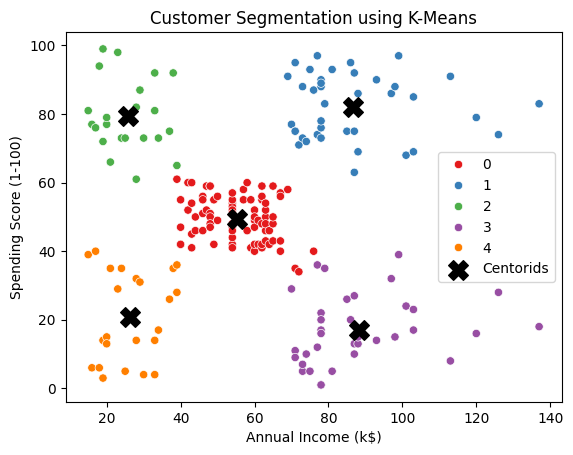

In [ ]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centorids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        2  
2        0  
3        2  
4        0  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 109.22822707921345
Silhouette Score: 0.49434988482196784


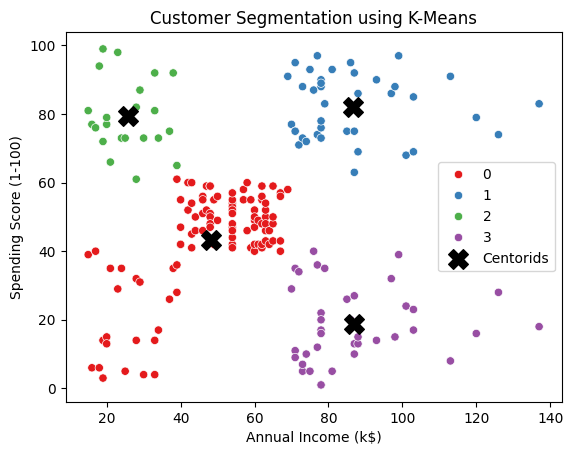

In [ ]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centorids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 157.70400815035939
Silhouette Score: 0.46658474419000145


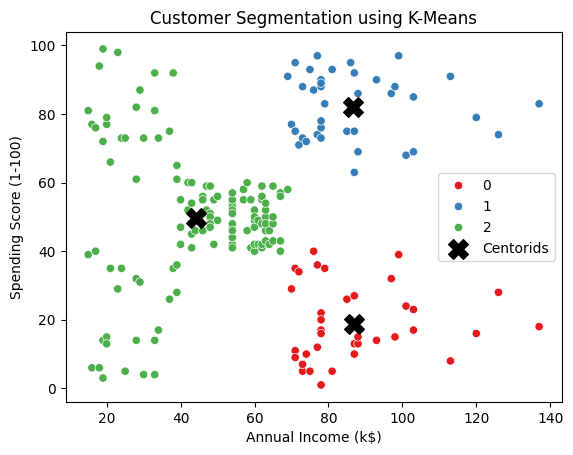

In [ ]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centorids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        2  
2        4  
3        2  
4        5  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 60.132874871934206
Silhouette Score: 0.5138257534676561


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        2  
2        4  
3        2  
4        5  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 60.132874871934206
Silhouette Score: 0.5138257534676561


In [ ]:
kmeans = KMeans(n_clusters=7, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        2  
2        4  
3        2  
4        5  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 49.668244837367965
Silhouette Score: 0.50200146805547


In [ ]:
kmeans = KMeans(n_clusters=8, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 37.31912287833882
Silhouette Score: 0.4550112502601921
